In [2]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset("huuuyeah/meetingbank")
print(ds)  # DatasetDict with train/validation/test

train_df = ds["train"].to_pandas()
val_df = ds["validation"].to_pandas()
test_df = ds["test"].to_pandas()

print(train_df.shape, val_df.shape, test_df.shape)
train_df.head()

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Generating test split: 100%|██████████| 862/862 [00:00<00:00, 12758.05 examples/s]


DatasetDict({
    train: Dataset({
        features: ['summary', 'uid', 'id', 'transcript'],
        num_rows: 5169
    })
    validation: Dataset({
        features: ['summary', 'uid', 'id', 'transcript'],
        num_rows: 861
    })
    test: Dataset({
        features: ['summary', 'uid', 'id', 'transcript'],
        num_rows: 862
    })
})
(5169, 4) (861, 4) (862, 4)


,summary,uid,id,transcript
0,AS AMENDED a bill for an ordinance amending th...,DenverCityCouncil_05012017_17-0161,0,Please refrain from profane or obscene speech....
1,AS AMENDED a bill for an ordinance amending th...,DenverCityCouncil_04102017_17-0161,1,An assessment has called out council bill 161 ...
2,AS AMENDED a bill for an ordinance amending th...,DenverCityCouncil_02272017_17-0161,2,I Please close the voting. Announce the result...
3,Recommendation to respectfully request City Co...,LongBeachCC_03072017_17-0161,3,"Motion passes. Hey, thank you very much. Now w..."
4,AS AMENDED a bill for an ordinance amending th...,DenverCityCouncil_03202017_17-0161,4,All right. Pursuant to Council Bill 3.7 consid...


In [ ]:
# checking for any null values
print(train_df.shape, val_df.shape, test_df.shape)
print(train_df.isnull().sum())
print((train_df["transcript"].str.strip() == "").sum())  # empty strings too

(5169, 4) (861, 4) (862, 4)
summary       0
uid           0
id            0
transcript    0
dtype: int64
0


In [4]:
'''we use tokenizer of BART and calculate the length of tokens in transcripts and summary
we take a sample of the data (300 rows) and then see the length of tokens so that we can get
an idea of whether to provide the input as chunk to the BART or not

maximum input token length of BART = 1024
maximum output token length of BART = 128
'''
from transformers import BartTokenizerFast

tokenizer = BartTokenizerFast.from_pretrained("facebook/bart-base")

def token_len(text):
    return len(tokenizer.encode(text, truncation=False))

# sample first — running this on all 5169 rows is slow-ish so we take sample
sample_df = train_df.sample(300, random_state=42)
sample_df["transcript_tokens"] = sample_df["transcript"].apply(token_len)
sample_df["summary_tokens"] = sample_df["summary"].apply(token_len)

print(sample_df[["transcript_tokens", "summary_tokens"]].describe())

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]
c:\Users\acer\briefgov\venv\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\acer\.cache\huggingface\hub\models--facebook--bart-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this

       transcript_tokens  summary_tokens
count         300.000000      300.000000
mean         3181.516667       81.726667
std          4814.670651       55.196081
min           174.000000       18.000000
25%           507.000000       45.000000
50%          1110.000000       70.000000
75%          3822.000000      103.250000
max         33850.000000      482.000000


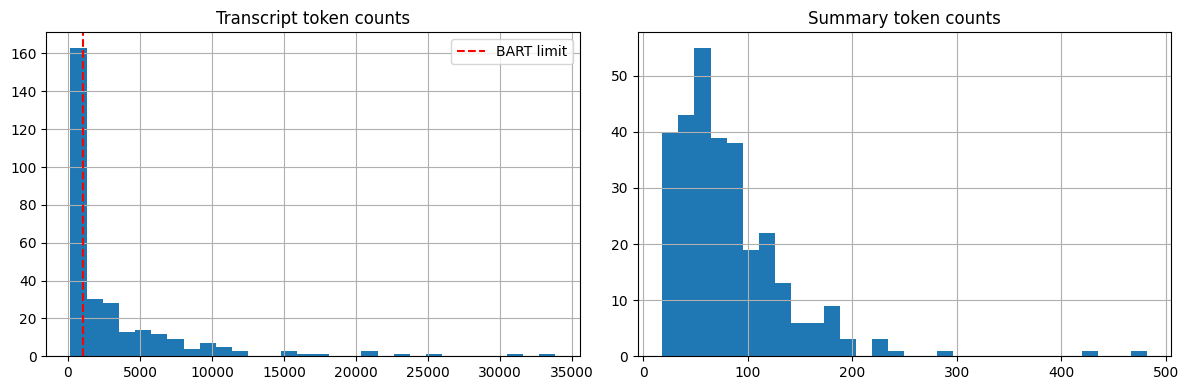

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sample_df["transcript_tokens"].hist(bins=30, ax=axes[0])
axes[0].set_title("Transcript token counts")
axes[0].axvline(1024, color='red', linestyle='--', label='BART limit')
axes[0].legend()

sample_df["summary_tokens"].hist(bins=30, ax=axes[1])
axes[1].set_title("Summary token counts")
plt.tight_layout()
plt.show()

In [7]:
over_limit = (sample_df["transcript_tokens"] > 1024).mean()
print(f"{over_limit:.1%} of sampled transcripts exceed 1024 tokens (BART limit)")

53.0% of sampled transcripts exceed 1024 tokens (BART limit)


In [10]:
import json

with open("../data/train_processed.jsonl", "r", encoding="utf-8") as f:
    lines = [json.loads(line) for i, line in enumerate(f) if i < 3]

for rec in lines:
    print("SOURCE:", rec["source"][:200], "...")
    print("TARGET:", rec["target"])
    print("---")

SOURCE: Please refrain from profane or obscene speech. Direct your comments to council as a whole and refrain from individual or personal attacks. Councilwoman Gilmore, will you please put Council Bill 161 on ...
TARGET: Some parking requirements are calculated based on gross floor area while others are on number of units and not explicitly for gross floor area, to further clarify the legislative intent of the proposed bill to emphasize the city’s commitment to more comprehensively address transportation demand management strategies in the short term, and to require a Zoning Permit with Informational Notice for all new buildings on Pre-Existing Small Zone Lots that request to use the small lot parking exemption; Enables all expansions to existing buildings to receive the full parking exemption; and clarifies at what point an “existing building” is considered AS AMENDED a bill for an ordinance amending the Denver Zoning Code to revise parking exemptions for pre-existing small zone lots.

In [11]:
for split in ["train", "validation", "test"]:
    with open(f"../data/{split}_processed.jsonl", "r", encoding="utf-8") as f:
        count = sum(1 for _ in f)
    print(f"{split}: {count} chunk-summary pairs")

train: 20597 chunk-summary pairs
validation: 3117 chunk-summary pairs
test: 3166 chunk-summary pairs
